In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

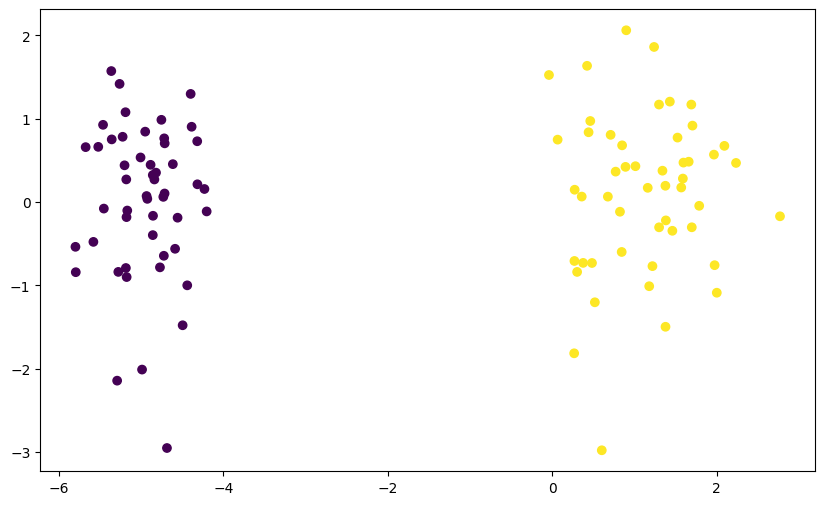

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[:, 0], X[:,1], c=y)
plt.show()

### Type 1 - Manual way of doing logistic regression

In [4]:
def perceptron(X,y):
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0, 100)
    y_hat = step(np.dot(X[j], weights))
    weights = weights + lr*(y[j] - y_hat) * X[j]

  return weights[0], weights[1:]


def step(z):
  return 1 if z > 0 else 0


[1.08682872 0.52024363]
1.2000000000000002


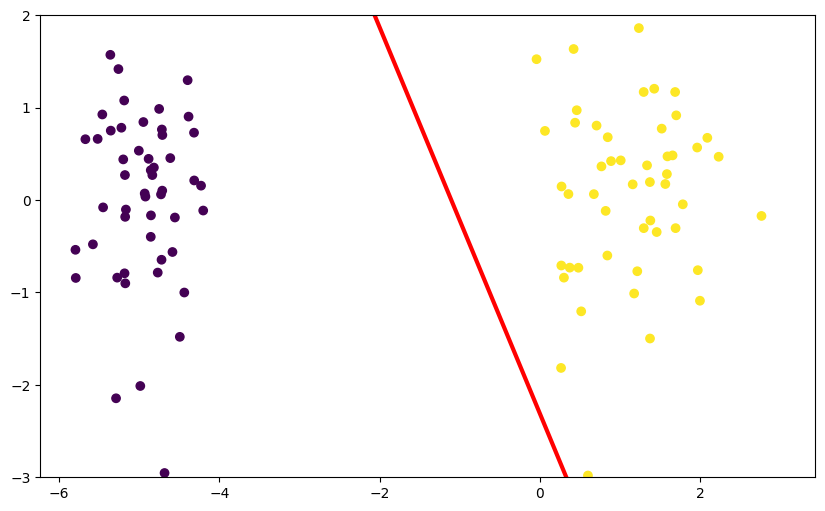

In [5]:
intercept_, coef_ = perceptron(X, y)

print(coef_)
print(intercept_)

m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b


plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y)
plt.ylim(-3,2)
plt.show()



### Type 2 - Doing Logistic Regression using Scikit Learn

(-3.0, 2.0)

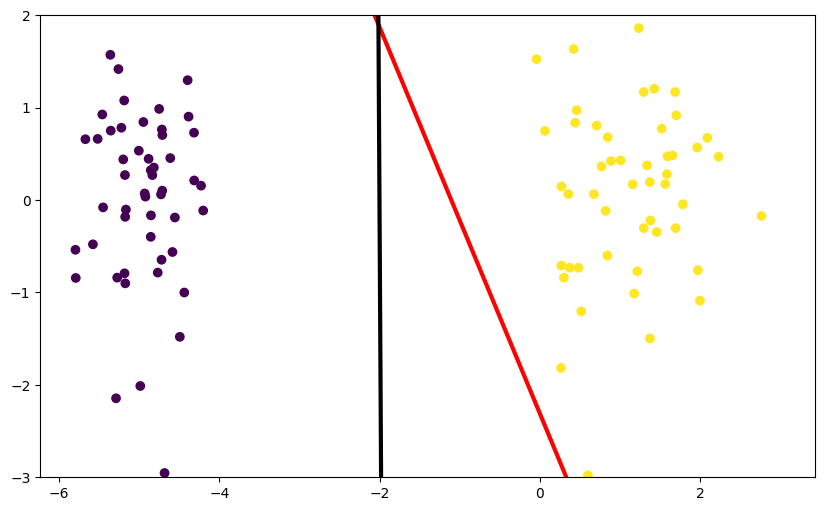

In [6]:
lr = LogisticRegression()
lr.fit(X,y)


m = -(lr.coef_[0][0]/lr.coef_[0][1])
b = -(lr.intercept_/lr.coef_[0][1])

x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b


plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)        # line by manual logistic reg
plt.plot(x_input1, y_input1, color='black', linewidth=3)    # line by scikit learn logistic reg
plt.scatter(X[:,0], X[:,1], c=y)
plt.ylim(-3,2)

